# Resutados priliminares de la exploración de datos

Este script reflejará el proceso en cuanto a la primera, segunda y tercera fase de la metodología en cuanto a la recolección, preparación y validación y el análisis exploratorio de datos respectivamente.

La estructura será una división de las tres fases; además, dentro de las fases se dividirá en los diferentes datos recolectados.

## Librerias y funciones

### Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
from scipy.stats import spearmanr
import libpysal
from esda.moran import Moran
from shapely import wkt
from shapely.geometry import Point

from scipy.stats import kruskal

### Funciones

In [2]:
# Función para obtener los datos de un archivo xlsx
def obtener_datos(url):
  data = pd.read_excel(url)
  return data

In [3]:
# Función para obtener los datos de un archivo xlsx de la ssf
def obtener_datos_ssf(url):
  data = pd.read_excel(url, sheet_name= "Motivo Producto")
  return data

In [4]:
# Función para obtener datos de un archivo csv
def obtener_datos_csv_v2(url):
    df_csv = pd.read_csv(url, on_bad_lines='skip')
    display(df_csv.head())
    return df_csv

In [5]:
# Función para obtener datos de un archivo csv
def obtener_dat_csv(url):
    df_csv = pd.read_csv(url)
    display(df_csv.head())
    return df_csv


In [6]:
# Función para ver la información del dataset
def info_dataset(da):
  da.info()

In [7]:
# Función para ver si se repiten las observaciones
def check_duplicados(df):
  duplicate_rows = df.duplicated().sum()
  print(f"Cantidad de registros duplicados: {duplicate_rows}")

In [8]:
# Función para eliminar las observaciones repetidas
def drop_duplicados(df):
  df_cleaned = df.drop_duplicates().reset_index(drop=True)
  return df_cleaned

In [9]:
# Función para ver datos nutos
def datos_nulos(da):
  print(da.isnull().sum())

In [10]:
# Función para ver en porcentaje los nulos de un dataframe
def porcentaje_nulos(da):
  print(da.isnull().mean())

In [11]:
# Función para extraer las columnas necesarias de un dataset
def extraer_columnas(da,columnas):
  da = da[columnas]
  return da

In [12]:
# Función para borrar columnas
def borrar_columnas(da,columnas):
  da = da.drop(columnas, axis=1)
  return da

In [13]:
# Función para cambiar el nombre de una columna
def cambiar_nombre_columna(da,columna1,columna2):
  da = da.rename(columns={columna1: columna2})
  return da

In [14]:
# Función para filtrar los datos
def filtrar_datos(da,columna,valor):
  da = da[da[columna] == valor]
  return da

In [15]:
def generar_mapa_correlacion(gdf_muni, df_master, gdf_rios):
    # Unimos los datos agregados al mapa
    resumen_muni = df_master.groupby('DIVIPOLA')['HECTAREAS'].sum().reset_index()
    mapa_datos = gdf_muni.merge(resumen_muni, left_on='DIVIPOLA_clean', right_on='DIVIPOLA')
    
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Dibujamos los municipios con el color según hectáreas afectadas
    mapa_datos.plot(column='HECTAREAS', cmap='YlOrRd', legend=True, ax=ax, 
                    legend_kwds={'label': "Hectáreas Afectadas Accumuladas"})
    
    # Superponemos la red hídrica (Ríos principales)
    gdf_rios.plot(ax=ax, color='black', linewidth=0.5, alpha=0.6, label='Red Hídrica Nacional')
    
    plt.title('Correspondencia Espacial: Inundaciones vs. Cuencas Hidrográficas')
    plt.show()

In [16]:
import matplotlib.colors as colors # Necesario para la escala logarítmica

def generar_mapa_correlacion_2(gdf_muni, df_master, gdf_rios):
    resumen_muni = df_master.groupby('DIVIPOLA')['HECTAREAS'].sum().reset_index()
    mapa_datos = gdf_muni.merge(resumen_muni, left_on='DIVIPOLA_clean', right_on='DIVIPOLA')
    
    fig, ax = plt.subplots(figsize=(12, 12), facecolor='white')
    
    # 1. Fondo de municipios: Gris neutro para que resalten los colores cálidos
    # Usamos norm=colors.LogNorm() para que los amarillos sean más vibrantes
    mapa_datos.plot(column='HECTAREAS', 
                    cmap='YlOrRd', 
                    legend=True, 
                    ax=ax,
                    edgecolor='white', # Borde blanco fino para separar
                    linewidth=0.2,
                    missing_kwds={'color': '#EEEEEE'}, # Municipios sin datos en gris claro
                    norm=colors.LogNorm(vmin=1, vmax=mapa_datos['HECTAREAS'].max()), # Escala Log
                    legend_kwds={'label': "Hectáreas Afectadas (Escala Log)", 'shrink': 0.5})
    
    # 2. Ríos: Azul oscuro/cian para que contrasten con el amarillo y rojo
    gdf_rios.plot(ax=ax, 
                  color='#005b96',   # Azul profundo
                  linewidth=0.6, 
                  alpha=0.7,         # Un poco más de opacidad para que sean visibles
                  label='Red Hídrica')
    
    plt.title('Correspondencia Espacial: Inundaciones vs. Cuencas Hidrográficas', fontsize=14)
    ax.axis('off')
    plt.show()


## Recolección de datos

### Atención emergencias

Estos datos fueron obtenidos por la UNGRD (Unidad Nacional para la Gestión del Riesgo de Desastres)

In [17]:
df_AE = obtener_datos('../Data_preparada/datos_inundaciones_v2.xlsx')

In [18]:
display(df_AE.head())

,FECHA,DIVIPOLA,DEPARTAMENTO,MUNICIPIO,EVENTO,CODIGO EMERGENCIA,PERSONAS,FAMILIAS,HECTAREAS,VIV.DESTRU.,...,ym,missing_divipola_flag,flood_crop_text_flag,hectareas_reported_flag,flood_crop_quantified_flag,flood_crop_any_flag,event_id_clean,housing_damage_proxy,infra_damage_proxy,support_fngrd_value
0,2024-02-07,19809.0,CAUCA,TIMBIQUI,INUNDACION,2468.0,2611.0,629.0,NaN,NaN,...,2024-02,0,1,0,0,1,2468.0,19,0,0.0
1,2024-03-13,27430.0,CHOCO,MEDIO BAUDO,INUNDACION,4342.0,12500.0,4050.0,760.0,7.0,...,2024-03,0,1,1,1,1,4342.0,7,0,0.0
2,2024-03-13,27025.0,CHOCO,ALTO BAUDO,INUNDACION,4352.0,15000.0,7500.0,23000.0,35.0,...,2024-03,0,1,1,1,1,4352.0,7535,10,0.0
3,2024-04-01,19809.0,CAUCA,TIMBIQUI,INUNDACION,5207.0,3391.0,980.0,633.0,4.0,...,2024-04,0,1,1,1,1,5207.0,125,2,0.0
4,2024-04-05,5147.0,ANTIOQUIA,CAREPA,INUNDACION,5304.0,7500.0,1875.0,270.0,NaN,...,2024-04,0,1,1,1,1,5304.0,0,0,0.0


In [19]:
# Información del dataset
info_dataset(df_AE)

<class 'pandas.DataFrame'>
RangeIndex: 1192 entries, 0 to 1191
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   FECHA                       1192 non-null   datetime64[us]
 1   DIVIPOLA                    1164 non-null   float64       
 2   DEPARTAMENTO                1192 non-null   str           
 3   MUNICIPIO                   1192 non-null   str           
 4   EVENTO                      1192 non-null   str           
 5   CODIGO EMERGENCIA           958 non-null    float64       
 6   PERSONAS                    939 non-null    float64       
 7   FAMILIAS                    986 non-null    float64       
 8   HECTAREAS                   434 non-null    float64       
 9   VIV.DESTRU.                 184 non-null    float64       
 10  VIV.AVER.                   755 non-null    float64       
 11  VIAS                        256 non-null    float64       
 12  ACU

In [20]:
# Limpiamos el codigo
df_AE["DIVIPOLA"] = (
    df_AE["DIVIPOLA"].astype(str).str.extract(r"(\d+)", expand=False).str.zfill(5)
)

### Áreas afectadas por inuncaciones niña 2011

Estos datos son obtenidos por medio de DATOS ABIERTOS del gobierno de Colombia, esta plataforma busca la transparencia de los datos de cualquier ambieto que afecte al crecimiento, información e historial del país.

Nombre: Áreas afectadas inundaciones
URL: https://www.datos.gov.co/Ambiente-y-Desarrollo-Sostenible/-reas-Afectadas-Inundaci-n-Ni-a-2011/jnwr-fzwi

Estos datos indica las zonas o áreas afectadas por inundaciones ocasionadas por el fenómeno de La Niña 2011, estos datos no han sido validados por el IDEAM, sin embargo, proporcionan información importante para los mapas.

In [21]:
df_inun11 = obtener_dat_csv('../Data/INUNDACION_CROQUIS/Áreas_afectadas_inundación_Nina_2_20251104.csv')

,the_geom,EMERGENCIA,AREA_HA,SHAPE_Length,SHAPE_Area,RULEID
0,MULTIPOLYGON (((-71.68359746699997 12.44480573...,Inundación,34.9650546875,0.061661,0.000029,1
1,MULTIPOLYGON (((-71.65074301799996 12.43575511...,Inundación,33.8826765625,0.066020,0.000028,1
2,MULTIPOLYGON (((-71.55765915999996 12.43277613...,Inundación,69.1998,0.045597,0.000057,1
3,MULTIPOLYGON (((-71.67079231799994 12.43400921...,Inundación,50.6739710937,0.090300,0.000042,1
4,MULTIPOLYGON (((-76.64102868999998 7.922784383...,Inundación,109.716951172,0.360826,0.000090,1


### Velocidad inundación de 20 años

In [22]:
# Problemas con el code
#df_vel20 = obtener_datos_csv_v2('Velocidad_Inundación_TR_20_Años_centros_poblados_E_1_2000_20251104.csv')

### Zonificación hidrográfica

In [23]:
df_hidro = obtener_dat_csv('../Data/INUNDACION_CROQUIS/Zonificación_Hidrográfica_Colombia_20251104.csv')

,the_geom,OBJECTID,COD_AH,nom_ah,COD_ZH,nom_zh,COD_SZH,nom_szh,ruleid,SHAPE_Length,SHAPE_Area
0,MULTIPOLYGON (((-76.08486990199998 5.685931743...,1,1,Caribe,11,Atrato - Darién,"1,101",Río Andágueda,2,1.807658,0.074302
1,MULTIPOLYGON (((-76.09414843199994 6.004175513...,2,1,Caribe,11,Atrato - Darién,"1,102",Alto Atrato,2,2.133416,0.134695
2,MULTIPOLYGON (((-76.54876382599997 5.504062701...,3,1,Caribe,11,Atrato - Darién,"1,103",Río Quito,2,2.590285,0.150004
3,MULTIPOLYGON (((-76.23252936799997 6.201064691...,4,1,Caribe,11,Atrato - Darién,"1,104",Río Bebaramá y otros Directos Atrato (md = mar...,2,2.308334,0.212143
4,MULTIPOLYGON (((-76.85708749899999 6.566185309...,5,1,Caribe,11,Atrato - Darién,"1,105",Directos Atrato entre ríos Quito y Bojayá (mi ...,2,3.189538,0.251700


In [24]:
# ==========================================
# 1. PROCESAR EL MAPA DE RÍOS / CUENCAS
# ==========================================
df_cuencas = pd.read_csv('../Data/INUNDACION_CROQUIS/Zonificación_Hidrográfica_Colombia_20251104.csv')

# Convertimos el texto (WKT) de la columna 'the_geom' a verdaderos polígonos matemáticos
df_cuencas['geometry'] = df_cuencas['the_geom'].apply(wkt.loads)

# Creamos el GeoDataFrame declarando que las coordenadas originales son GPS estándar (EPSG:4326)
gdf_cuencas = gpd.GeoDataFrame(df_cuencas, geometry='geometry', crs="EPSG:4326")

# PROYECCIÓN ACTUARIAL (VITAL): Convertimos a metros (EPSG:9377 Magna Sirgas)
gdf_cuencas = gdf_cuencas.to_crs(epsg=9377)

### DIVIPOLA_Municipios

In [25]:
# ==========================================
# 2. PROCESAR EL MAPA DE MUNICIPIOS
# ==========================================
# Ajusta el 'skiprows' si es necesario. Según tu archivo, los datos empiezan por la fila 11 o 12.
df_muni = pd.read_excel('../Data/DIVIPOLA_Municipios.xlsx', skiprows=10)

# Limpiamos nombres de columnas y filtramos los que sí tienen coordenadas
df_muni = df_muni.rename(columns={' Código .1': 'DIVIPOLA_MUNI', ' Nombre .1': 'MUNICIPIO'})
df_muni = df_muni.dropna(subset=['Longitud', 'Latitud'])

# Convertimos Longitud y Latitud a Puntos geométricos
df_muni['geometry'] = df_muni.apply(lambda row: Point(row['Longitud'], row['Latitud']), axis=1)

# Creamos el GeoDataFrame y lo proyectamos a metros igual que las cuencas
gdf_muni = gpd.GeoDataFrame(df_muni, geometry='geometry', crs="EPSG:4326")
gdf_muni = gdf_muni.to_crs(epsg=9377)

info_dataset(gdf_muni)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 9 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   Código                                 1122 non-null   str     
 1   Nombre                                 1122 non-null   str     
 2    Código                                1122 non-null   float64 
 3    Nombre                                1122 non-null   str     
 4   Municipio
Isla
Área no municipalizada  1122 non-null   str     
 5   Longitud                               1122 non-null   float64 
 6   Latitud                                1122 non-null   float64 
 7   Nota                                   4 non-null      str     
 8   geometry                               1122 non-null   geometry
dtypes: float64(3), geometry(1), str(5)
memory usage: 111.6 KB


In [26]:
gdf_muni.columns

Index(['Código', 'Nombre', ' Código ', ' Nombre ',
       'Municipio\nIsla\nÁrea no municipalizada', 'Longitud', 'Latitud',
       'Nota', 'geometry'],
      dtype='str')

In [27]:
gdf_muni.head()

,Código,Nombre,Código,Nombre,Municipio\nIsla\nÁrea no municipalizada,Longitud,Latitud,Nota,geometry
0,05,ANTIOQUIA,5001.0,MEDELLÍN,Municipio,-75.581775,6.246631,NaN,POINT (4714426.742 2248941.488)
1,05,ANTIOQUIA,5002.0,ABEJORRAL,Municipio,-75.428739,5.789315,NaN,POINT (4731139.616 2198283.606)
2,05,ANTIOQUIA,5004.0,ABRIAQUÍ,Municipio,-76.064304,6.632282,NaN,POINT (4661263.723 2291902.347)
3,05,ANTIOQUIA,5021.0,ALEJANDRÍA,Municipio,-75.141346,6.376061,NaN,POINT (4763226.554 2263034.501)
4,05,ANTIOQUIA,5030.0,AMAGÁ,Municipio,-75.702188,6.038708,NaN,POINT (4700982.058 2226008.068)


In [28]:
# Extraemos el código limpio a 5 dígitos
gdf_muni['DIVIPOLA_clean'] = gdf_muni[' Código '].astype(str).str.extract(r'(\d+)', expand=False).str.zfill(5)


# ==========================================
# 3. CÁLCULO DE LA DISTANCIA HIDROLÓGICA
# ==========================================
# Esta función busca la distancia mínima en metros desde el casco urbano (Punto) 
# hasta el borde de la cuenca/río (Polígono) más cercano.
def calcular_distancia_minima(punto_muni):
    return gdf_cuencas.distance(punto_muni).min()

# Aplicamos el cálculo a todos los municipios
gdf_muni['distancia_rio_metros'] = gdf_muni.geometry.apply(calcular_distancia_minima)

# Redondeamos a kilómetros para que sea más fácil de interpretar en el modelo
gdf_muni['distancia_rio_km'] = gdf_muni['distancia_rio_metros'] / 1000

print(gdf_muni[['DIVIPOLA_clean', ' Nombre ', 'distancia_rio_km']].head())

  DIVIPOLA_clean     Nombre   distancia_rio_km
0          05001    MEDELLÍN               0.0
1          05002   ABEJORRAL               0.0
2          05004    ABRIAQUÍ               0.0
3          05021  ALEJANDRÍA               0.0
4          05030       AMAGÁ               0.0


In [29]:
info_dataset(gdf_muni)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   Código                                 1122 non-null   str     
 1   Nombre                                 1122 non-null   str     
 2    Código                                1122 non-null   float64 
 3    Nombre                                1122 non-null   str     
 4   Municipio
Isla
Área no municipalizada  1122 non-null   str     
 5   Longitud                               1122 non-null   float64 
 6   Latitud                                1122 non-null   float64 
 7   Nota                                   4 non-null      str     
 8   geometry                               1122 non-null   geometry
 9   DIVIPOLA_clean                         1122 non-null   str     
 10  distancia_rio_metros                   1122 non-null

### Quejas superfinanciera

In [30]:
df_quejas = obtener_datos_ssf("../Data/QUEJAS_SUPERFINANCIERA/Superfinanciera/quejassfcanual19.xlsx")

In [31]:
display(df_quejas.head())

,Motivos Productos,Acciones,Administración de sistemas de pago de bajo valor,Administración de valores,"Administración otros fondos (mutuos, portafolios de terceros y/o de capital extranjero)",C.D.T.,CDAT,CDT,Cesantías,Contrato de comisión,...,Seguro previsional de invalidez y sobreviviencia,Seguro todo riesgo contratista,Servicios de corresponsales no bancarios (CNB),Servicios de proveedores de infraestructura – otros,Sin clasificar,Tarjetas de crédito,Titularización fiduciaria,Títulos de capitalización,#N/A,Total general
0,Revisión y/o Liquidación,NaN,NaN,NaN,NaN,NaN,2.0,107.0,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,5594.0,NaN,39.0,NaN,15024
1,Aspectos contractuales (Incumplimiento y/o mod...,NaN,NaN,5.0,1.0,NaN,64.0,138.0,89.0,29.0,...,NaN,NaN,NaN,1.0,NaN,1994.0,NaN,NaN,NaN,11027
2,Indebida atención al consumidor financiero-ser...,NaN,39.0,NaN,NaN,1.0,25.0,68.0,120.0,NaN,...,NaN,NaN,62.0,NaN,NaN,2199.0,1.0,18.0,1.0,8497
3,Sin clasificar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7218.0,NaN,NaN,NaN,NaN,7219
4,Cobro servicios y/o comisiones,NaN,5.0,12.0,1.0,1.0,NaN,7.0,NaN,4.0,...,NaN,NaN,4.0,NaN,NaN,2711.0,NaN,NaN,NaN,4494


In [32]:
df_quejas.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 87 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   Motivos                                                           Productos              174 non-null    str    
 1   Acciones                                                                                 13 non-null     float64
 2   Administración de sistemas de pago de bajo valor                                         8 non-null      float64
 3   Administración de valores                                                                7 non-null      float64
 4   Administración otros fondos (mutuos, portafolios de terceros y/o de capital extranjero)  5 non-null      float64
 5   C.D.T.                                                                     

### Zonificacion para el cultivo

In [33]:
#df_cultivo = obtener_dat_csv("Zonificación_de_aptitud_para_el_cultivo_comercial_de_aguacate_(Persea_americana_Mill.),_variedad_Hass_en_Colombia._20251104.csv")

## Preparación y validación de datos

Se realizar la preparación y validación de datos tal cual se realizo en la recolección de datos, es decir, tener la misma estructura.

### Atención emergencias

Estos datos ya tuvieron su limpieza y filtración en otro script

### Áreas afectadas por inundaciones niña 2011

In [34]:
# Check for missing values in df_inun11
print("Missing values in df_inun11:")
print(df_inun11.isnull().sum())

Missing values in df_inun11:
the_geom        0
EMERGENCIA      0
AREA_HA         0
SHAPE_Length    0
SHAPE_Area      0
RULEID          0
dtype: int64


## Análisis exploratorio de los datos

Como las anteriores fases, se realizará un análisis exploratorio de los datos siguiendo la organización expuesta anteriormente, por otro lado, este fase permitirá responde a resultados pre-liminares.

### Atención emergencias

In [35]:
# Calculate the total affected hectares from df_AE
df_AE['HECTAREAS'] = pd.to_numeric(df_AE['HECTAREAS'], errors='coerce')
total_hectares_ae = df_AE['HECTAREAS'].sum()
print(f"Total hectareas afectadas (df_AE): {total_hectares_ae}")

Total hectareas afectadas (df_AE): 350029.631


In [36]:
# Convert columns to numeric, coercing errors
df_AE['FAMILIAS'] = pd.to_numeric(df_AE['FAMILIAS'], errors='coerce')
df_AE['PERSONAS'] = pd.to_numeric(df_AE['PERSONAS'], errors='coerce')

# Calculate the average affected families and people
average_families = df_AE['FAMILIAS'].mean()
average_people = df_AE['PERSONAS'].mean()

print(f"Promedio de afectacción por familia (df_AE): {average_families}")
print(f"Promedio de afectacción por persona (df_AE): {average_people}")

Promedio de afectacción por familia (df_AE): 443.33569979716026
Promedio de afectacción por persona (df_AE): 1784.6059637912674


Inundación

In [37]:
# Filter for inundation events
inundation_events_ae = df_AE[df_AE['EVENTO'] == 'INUNDACION']

# Count events per year
inundation_events_by_year = inundation_events_ae['year'].value_counts().sort_index()

print("Numbero de inundaciones por año (df_AE):")
print(inundation_events_by_year)

Numbero de inundaciones por año (df_AE):
year
2010     18
2011     89
2012     68
2013     67
2014     70
2015     47
2016     71
2017     93
2018      6
2019     61
2020     97
2021    150
2022    162
2023     69
2024    124
Name: count, dtype: int64


In [38]:
# Create a quarter column
df_AE['FECHA_trimestre'] = pd.to_datetime(df_AE['month'], format='%m').dt.quarter

# Filter for inundation events
inundation_events_ae = df_AE[df_AE['EVENTO'] == 'INUNDACION']

# Count events by quarter
inundation_events_by_quarter = inundation_events_ae['FECHA_trimestre'].value_counts().sort_index()

print("Number of inundation events per quarter (df_AE):")
print(inundation_events_by_quarter)

Number of inundation events per quarter (df_AE):
FECHA_trimestre
1    115
2    532
3    259
4    286
Name: count, dtype: int64


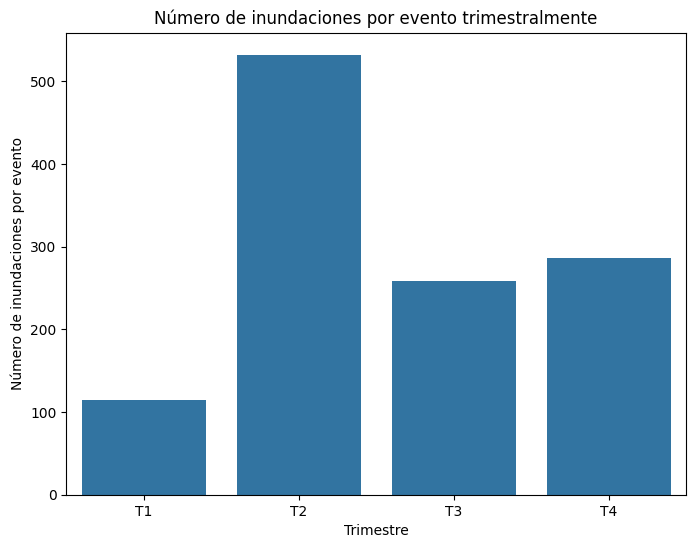

In [39]:
# Visualize inundation events per quarter
plt.figure(figsize=(8, 6))
sns.barplot(x=inundation_events_by_quarter.index, y=inundation_events_by_quarter.values)
plt.xlabel('Trimestre')
plt.ylabel('Número de inundaciones por evento')
plt.title('Número de inundaciones por evento trimestralmente')
plt.xticks(ticks=[0, 1, 2, 3], labels=['T1', 'T2', 'T3', 'T4'])
plt.show()

In [40]:
# Group by department and sum hectares and families
df_department_severity = df_AE.groupby('DEPARTAMENTO').agg({
    'HECTAREAS': 'sum',
    'FAMILIAS': 'sum'
}).reset_index()

# Calculate agricultural severity by department
df_department_severity['severidad_agricola_departamento'] = df_department_severity['HECTAREAS'] / df_department_severity['FAMILIAS']

# Replace infinite values with NaN
df_department_severity['severidad_agricola_departamento'] = df_department_severity['severidad_agricola_departamento'].replace([np.inf, -np.inf], np.nan)

# Display the result
display(df_department_severity)

,DEPARTAMENTO,HECTAREAS,FAMILIAS,severidad_agricola_departamento
0,AMAZONAS,0.000,3553.0,0.000000
1,ANTIOQUIA,15361.800,33761.0,0.455016
2,ARAUCA,10106.000,17410.0,0.580471
3,ATLANTICO,1019.000,2008.0,0.507470
4,BOLIVAR,64263.511,58782.0,1.093252
5,BOYACA,13169.900,5588.0,2.356818
6,CALDAS,0.000,55.0,0.000000
7,CAQUETA,5197.500,6983.0,0.744308
8,CASANARE,3647.000,8288.0,0.440034
9,CAUCA,29377.440,37906.0,0.775008


### Áreas afectadas por inundación La Niña 2011

Generating map...


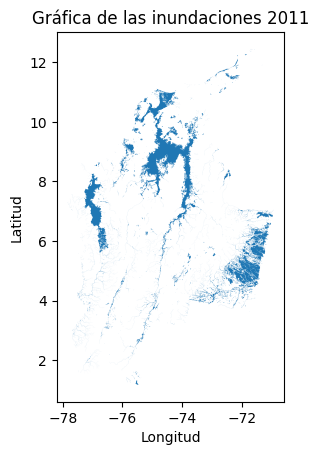

In [41]:
import geopandas as gpd
from shapely import wkt

# Convert 'the_geom' column from WKT to geometry objects
df_inun11['geometry'] = df_inun11['the_geom'].apply(wkt.loads)

# Create a GeoDataFrame
gdf_inun11 = gpd.GeoDataFrame(df_inun11, geometry='geometry')

# Plot the geographical data
print("Generating map...")
gdf_inun11.plot()
plt.title('Gráfica de las inundaciones 2011')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

### Zonificación hidrográfica

Generating map...


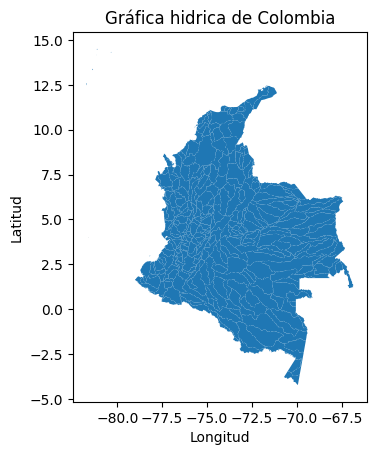

In [42]:
import geopandas as gpd
from shapely import wkt

# Convert 'the_geom' column from WKT to geometry objects
df_hidro['geometry'] = df_hidro['the_geom'].apply(wkt.loads)

# Create a GeoDataFrame
gdf_hidro = gpd.GeoDataFrame(df_hidro, geometry='geometry')

# Plot the geographical data
print("Generating map...")
gdf_hidro.plot()
plt.title('Gráfica hidrica de Colombia')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

In [43]:
# Show summary statistics for df_hidro
display(df_hidro.describe(include='all'))

,the_geom,OBJECTID,COD_AH,nom_ah,COD_ZH,nom_zh,COD_SZH,nom_szh,ruleid,SHAPE_Length,SHAPE_Area,geometry
count,316,316.000000,316.000000,316,316.000000,316,316,316,316.000000,316.000000,316.000000,316
unique,316,NaN,NaN,5,NaN,40,316,314,NaN,NaN,NaN,316
top,MULTIPOLYGON (((-76.08486990199998 5.685931743...,NaN,NaN,Magdalena Cauca,NaN,Cauca,"1,101",Río San Juan,NaN,NaN,NaN,MULTIPOLYGON (((-76.08486990199998 5.685931743...
freq,1,NaN,NaN,105,NaN,36,1,2,NaN,NaN,NaN,1
mean,NaN,158.500000,2.778481,NaN,31.867089,NaN,NaN,NaN,2.946203,3.426907,0.293770,NaN
std,NaN,91.365566,1.222142,NaN,12.362567,NaN,NaN,NaN,1.242227,2.042895,0.274988,NaN
min,NaN,1.000000,1.000000,NaN,11.000000,NaN,NaN,NaN,1.000000,0.072657,0.000051,NaN
25%,NaN,79.750000,2.000000,NaN,23.000000,NaN,NaN,NaN,2.000000,2.053433,0.104742,NaN
50%,NaN,158.500000,3.000000,NaN,32.000000,NaN,NaN,NaN,3.000000,2.994307,0.205359,NaN
75%,NaN,237.250000,4.000000,NaN,42.000000,NaN,NaN,NaN,4.000000,4.366333,0.404689,NaN


### Justificación 5.1.3. (Registro e inundaciones)

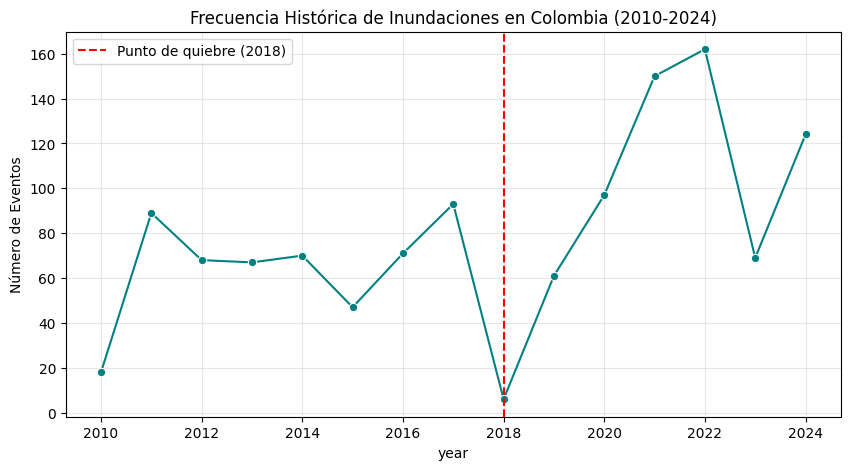

Resumen de Impacto por Departamento:
              HECTAREAS  promedio_personas_evento  total_eventos
DEPARTAMENTO                                                    
BOLIVAR       64263.511               2592.101695             76
CHOCO         48080.000               3798.458015            150
SUCRE         37471.500               1509.851852             32
PUTUMAYO      30518.500               2398.160714             59
CAUCA         29377.440               2582.870968             78
CORDOBA       21834.300               3131.678571             35
SANTANDER     16672.000                557.628571             62
ANTIOQUIA     15361.800               1281.568182            102
META          14220.500                478.017241             79
BOYACA        13169.900                573.127660             51


In [44]:
# 1.1 Gráfica de Frecuencia Temporal (Validar incremento desde 2018)
frecuencia_anual = df_AE.groupby('year').size().reset_index(name='num_eventos')

plt.figure(figsize=(10, 5))
sns.lineplot(data=frecuencia_anual, x='year', y='num_eventos', marker='o', color='teal')
plt.axvline(2018, color='red', linestyle='--', label='Punto de quiebre (2018)')
plt.title('Frecuencia Histórica de Inundaciones en Colombia (2010-2024)')
plt.ylabel('Número de Eventos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 1.2 Tabla de Impacto por Departamento (Bolívar, Chocó, Sucre)
impacto_depto = df_AE.groupby('DEPARTAMENTO').agg({
    'HECTAREAS': 'sum',
    'PERSONAS': 'mean',
    'EVENTO': 'count'
}).rename(columns={'EVENTO': 'total_eventos', 'PERSONAS': 'promedio_personas_evento'})

# Filtrar los 10 departamentos más afectados por hectáreas
top_10_hectareas = impacto_depto.sort_values('HECTAREAS', ascending=False).head(10)
print("Resumen de Impacto por Departamento:")
print(top_10_hectareas)

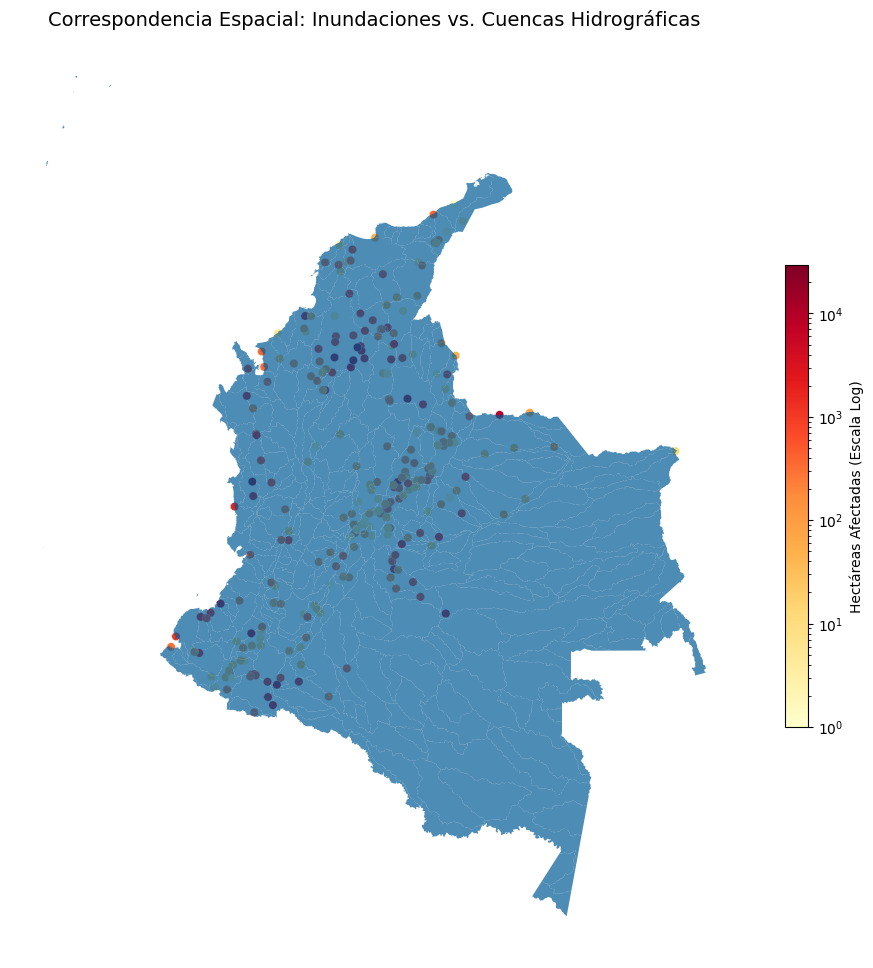

In [45]:
generar_mapa_correlacion_2(gdf_muni, df_AE, gdf_cuencas)

### Justificación 5.2 (Sintesis e interpretación)

In [46]:
# gdf_muni = gpd.read_file('municipios.shp')
# gdf_rios = gpd.read_file('rios_principales.shp')

# 1. Preparar datos a nivel municipal
resumen_muni = df_AE.groupby('DIVIPOLA')['HECTAREAS'].sum().fillna(0).reset_index()
gdf_muni_datos = gdf_muni.merge(resumen_muni, left_on='DIVIPOLA_clean', right_on='DIVIPOLA', how='left')

# ========================================================
# TEST 1: Índice de Moran (Autocorrelación Espacial)
# ========================================================
# Rellenar nulos con 0 para el test
y = gdf_muni_datos['HECTAREAS'].fillna(0).values

# Crear matriz de pesos espaciales (quién es vecino de quién)
w = libpysal.weights.Queen.from_dataframe(gdf_muni_datos)
w.transform = 'r' # Estandarización por filas

# Calcular Moran's I
moran = Moran(y, w)
print(f"Índice de Moran Global: {moran.I:.4f}")
print(f"P-valor: {moran.p_sim:.4f}")

# ========================================================
# TEST 2: Correlación de Spearman (Distancia a Ríos)
# ========================================================
# Convertir a sistema de coordenadas proyectado (metros) para medir distancia
gdf_muni_datos = gdf_muni_datos.to_crs(epsg=9377)
gdf_cuencas = gdf_cuencas.to_crs(epsg=9377)

# Calcular la distancia desde el centroide de cada municipio al río más cercano
gdf_muni_datos['distancia_rio_m'] = gdf_muni_datos.geometry.centroid.apply(
    lambda x: gdf_cuencas.distance(x).min()
)

print("ANÁLISIS DE VARIANZA HIDROLÓGICA")

# 1. Asignar cada municipio a su Macro-Cuenca (Área Hidrográfica - nom_ah)
# Usamos los centroides de los municipios para ver en qué polígono de cuenca caen
gdf_muni_centroides = gdf_muni_datos.copy()
gdf_muni_centroides.geometry = gdf_muni_centroides.geometry.centroid

# Cruce espacial (Spatial Join)
muni_cuencas = gpd.sjoin(
    gdf_muni_centroides, 
    gdf_cuencas[['nom_ah', 'geometry']], 
    how='left', 
    predicate='intersects'
)

# 2. Imprimir la evidencia (Hectáreas concentradas por cuenca)
resumen_cuencas = muni_cuencas.groupby('nom_ah')['HECTAREAS'].sum().fillna(0).sort_values(ascending=False)
print("\nDistribución de Pérdidas por Sistema Fluvial:")
print(resumen_cuencas)

# 3. Test Estadístico de Kruskal-Wallis (ANOVA no paramétrico)
# Agrupamos los datos de hectáreas afectadas por cada cuenca
grupos_cuencas = [grupo['HECTAREAS'].fillna(0).values for nombre, grupo in muni_cuencas.groupby('nom_ah')]

# Ejecutamos el test
stat_kw, p_valor_kw = kruskal(*grupos_cuencas)
print(f"\nTest de Kruskal-Wallis: Nivel de significancia") # H = {stat_kw:.4f}"
print(f"P-valor: {p_valor_kw:.4e}")

C:\Users\sierr\AppData\Local\Temp\ipykernel_7024\3469519613.py:15: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(gdf_muni_datos)


Índice de Moran Global: 0.2621
P-valor: 0.0010
ANÁLISIS DE VARIANZA HIDROLÓGICA

Distribución de Pérdidas por Sistema Fluvial:
nom_ah
Magdalena Cauca    155789.261
Pacifico            77173.270
Amazonas            36731.000
Orinoco             35621.800
Caribe              21293.300
Name: HECTAREAS, dtype: float64

Test de Kruskal-Wallis: Nivel de significancia
P-valor: 5.7458e-03


In [ ]:
# Definir un valor promedio conser.vador de 1 hectárea de cultivo (ej. 5 millones de COP)
VALOR_HA_COP = 5_000_000 

# Calcular la Pérdida Económica Estimada (VaR destruido)
df_AE['perdida_estimada_cop'] = df_AE['HECTAREAS'] * VALOR_HA_COP

# Llenar nulos en las ayudas del FNGRD con 0
df_AE['support_fngrd_value'] = df_AE['support_fngrd_value'].fillna(0)

# Calcular Brecha de Protección y Tasa de Penetración (Cobertura Estatal)
total_perdida = df_AE['perdida_estimada_cop'].sum()
total_ayudas = df_AE['support_fngrd_value'].sum()

brecha_proteccion = total_perdida - total_ayudas
tasa_penetracion = (total_ayudas / total_perdida) * 100

print(f"Pérdida Económica Estimada Total: ${total_perdida:,.0f} COP")
print(f"Total Ayudas/Compensación (FNGRD): ${total_ayudas:,.0f} COP")
print(f"Brecha de Protección (No asegurado): ${brecha_proteccion:,.0f} COP")
print(f"Tasa de Penetración/Cobertura Equivalente: {tasa_penetracion:.2f}%")

Pérdida Económica Estimada Total: $1,750,148,155,000 COP
Total Ayudas/Compensación (FNGRD): $170,482,388,689 COP
Brecha de Protección (No asegurado): $1,579,665,766,311 COP
Tasa de Penetración/Cobertura Equivalente: 9.74%


### Quejas

In [48]:
# Identify columns related to the insurance sector (assuming columns with 'Seguro' or similar in their name), excluding 'Total general'
insurance_columns = [col for col in df_quejas.columns if ('Seguro' in col or 'seguro' in col) and col != 'Total general']

# Sum the complaints for each row across the identified insurance columns
df_quejas['Total_Seguros'] = df_quejas[insurance_columns].sum(axis=1, numeric_only=True)

# Find the row with the maximum total complaints in the insurance sector
max_complaints_row = df_quejas.loc[df_quejas['Total_Seguros'].idxmax()]

# Get the 'Motivos' for the product with the maximum complaints
product_with_max_complaints = max_complaints_row['Motivos                                                           Productos']

print(f"The product with the highest number of complaints in the insurance sector (excluding 'Total general') is: {product_with_max_complaints}")

The product with the highest number of complaints in the insurance sector (excluding 'Total general') is: Total general


In [49]:
# Select the specified insurance columns and the 'Motivos Productos' column
selected_insurance_columns = ['Motivos                                                           Productos',
                              'Seguro agropecuario', 'Intermediación en Seguros y reaSeguros', 'Total_Seguros']
df_selected_insurance = df_quejas[selected_insurance_columns]

# Display the selected columns
display(df_selected_insurance.head())

# Calculate the total complaints for each of the selected specific insurance types
total_seguro_agropecuario = df_selected_insurance['Seguro agropecuario'].sum()
total_intermediacion_seguros = df_selected_insurance['Intermediación en Seguros y reaSeguros'].sum()
total_all_insurance = df_selected_insurance['Total_Seguros'].sum()


print(f"\nTotal de denuncias por 'Seguro agropecuario'': {total_seguro_agropecuario}")
print(f"Total de denuncias por 'Intermediación en Seguros y reaSeguros': {total_intermediacion_seguros}")
print(f"Total de reclamaciones en todas las categorías de seguros: {total_all_insurance}")

# Compare the number of complaints
print("\Comparación:")
if total_seguro_agropecuario > total_intermediacion_seguros:
    print("'Seguro agropecuario' tiene más quejas que 'Intermediación en Seguros y reaSeguros'.")
elif total_seguro_agropecuario < total_intermediacion_seguros:
    print("'Seguro agropecuario' tiene menos quejas que 'Intermediación en Seguros y reaSeguros'.")
else:
    print("'Seguro agropecuario e Intermediación en Seguros y reaSeguros tienen el mismo número de denuncias.")

if total_seguro_agropecuario > total_all_insurance:
    print("''Seguro agropecuario' tiene más reclamaciones que el total de todas las categorías de seguros (Esto es inesperado y podría indicar un problema con los datos o el cálculo).")
elif total_seguro_agropecuario < total_all_insurance:
     print("'Seguro agropecuario' tiene menos reclamaciones que el total de todas las categorías de seguros.")
else:
    print("'El seguro agropecuario registra el mismo número de reclamaciones que el total de todas las categorías de seguros.")

<>:20: SyntaxWarning: invalid escape sequence '\C'
<>:20: SyntaxWarning: invalid escape sequence '\C'
C:\Users\sierr\AppData\Local\Temp\ipykernel_7024\2854758083.py:20: SyntaxWarning: invalid escape sequence '\C'
  print("\Comparación:")


,Motivos Productos,Seguro agropecuario,Intermediación en Seguros y reaSeguros,Total_Seguros
0,Revisión y/o Liquidación,NaN,NaN,115.0
1,Aspectos contractuales (Incumplimiento y/o mod...,NaN,NaN,1710.0
2,Indebida atención al consumidor financiero-ser...,NaN,1.0,266.0
3,Sin clasificar,NaN,NaN,0.0
4,Cobro servicios y/o comisiones,NaN,NaN,24.0



Total de denuncias por 'Seguro agropecuario'': 6.0
Total de denuncias por 'Intermediación en Seguros y reaSeguros': 6.0
Total de reclamaciones en todas las categorías de seguros: 19544.0
\Comparación:
'Seguro agropecuario e Intermediación en Seguros y reaSeguros tienen el mismo número de denuncias.
'Seguro agropecuario' tiene menos reclamaciones que el total de todas las categorías de seguros.


In [50]:
# Check the column names of df_quejas
print(df_quejas.columns)

Index(['Motivos                                                           Productos',
       'Acciones', 'Administración de sistemas de pago de bajo valor',
       'Administración de valores',
       'Administración otros fondos (mutuos, portafolios de terceros y/o de capital extranjero)',
       'C.D.T.', 'CDAT', 'CDT', 'Cesantías', 'Contrato de comisión',
       'Contrato de corresponsalía', 'Crédito de consumo y/o comercial',
       'Crédito de vivienda', 'Cuenta corriente', 'Cuenta de ahorros',
       'Fiducia admón. Inmobiliaria proyectos de construcción',
       'Fiducia de administración', 'Fiducia de garantía',
       'Fiducia de inversión', 'Fiducia pública',
       'Fondos comunes ordinarios y especiales (FCO  Y FCE)',
       'Fondos de valores y/o de inversión',
       'Giros establecimientos de crédito',
       'Intermediación de mercado cambiario (giros, compraventa de divisas)',
       'Intermediación de valores', 'Intermediación en Seguros y reaSeguros',
       'Leasing'

###

# Los siguientes modelos son un croquis/borrador del dataset definitivo

In [51]:
bhj # Llave de control

NameError: name 'bhj' is not defined

## Data preparation for u-net

### Subtask:
Convert the geospatial data from `df_inun11` into a format suitable for image input to a U-Net model. This might involve rasterizing the affected areas to create binary masks (segmentation targets) and potentially preparing corresponding input images (e.g., satellite imagery or other relevant spatial data).


**Reasoning**:
Convert the 'the_geom' column to geometry objects and create a GeoDataFrame, then determine the appropriate spatial resolution and extent for rasterization based on the GeoDataFrame's bounds.



In [ ]:
from shapely import wkt
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds

# Convert 'the_geom' column from WKT to geometry objects
df_inun11['geometry'] = df_inun11['the_geom'].apply(wkt.loads)

# Create a GeoDataFrame
gdf_inun11 = gpd.GeoDataFrame(df_inun11, geometry='geometry')

# Determine the bounds of the GeoDataFrame
minx, miny, maxx, maxy = gdf_inun11.total_bounds

# Determine appropriate resolution (example: 100x100 grid)
resolution = 0.01 # Adjust based on desired level of detail and computational resources
width = int((maxx - minx) / resolution)
height = int((maxy - miny) / resolution)

# Create a transform for the raster
transform = from_bounds(minx, miny, maxx, maxy, width, height)

print(f"Raster dimensions: width={width}, height={height}")
print(f"Raster transform: {transform}")

Raster dimensions: width=693, height=1127
Raster transform: | 0.01, 0.00,-77.85|
| 0.00,-0.01, 12.45|
| 0.00, 0.00, 1.00|


**Reasoning**:
The previous command failed because the `rasterio` library is not installed. Install the library to proceed with rasterization.



In [ ]:
%pip install rasterio geopandas

**Reasoning**:
Now that `rasterio` and `geopandas` are installed, convert the 'the_geom' column to geometry objects and create a GeoDataFrame. Then, determine the appropriate spatial resolution and extent for rasterization based on the GeoDataFrame's bounds.



In [ ]:
from shapely import wkt
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds

# Convert 'the_geom' column from WKT to geometry objects
df_inun11['geometry'] = df_inun11['the_geom'].apply(wkt.loads)

# Create a GeoDataFrame
gdf_inun11 = gpd.GeoDataFrame(df_inun11, geometry='geometry')

# Determine the bounds of the GeoDataFrame
minx, miny, maxx, maxy = gdf_inun11.total_bounds

# Determine appropriate resolution (example: 100x100 grid)
resolution = 0.01 # Adjust based on desired level of detail and computational resources
width = int((maxx - minx) / resolution)
height = int((maxy - miny) / resolution)

# Create a transform for the raster
transform = from_bounds(minx, miny, maxx, maxy, width, height)

print(f"Raster dimensions: width={width}, height={height}")
print(f"Raster transform: {transform}")

Raster dimensions: width=693, height=1127
Raster transform: | 0.01, 0.00,-77.85|
| 0.00,-0.01, 12.45|
| 0.00, 0.00, 1.00|


**Reasoning**:
Rasterize the 'geometry' column of the GeoDataFrame onto the template raster to create binary masks (segmentation targets).



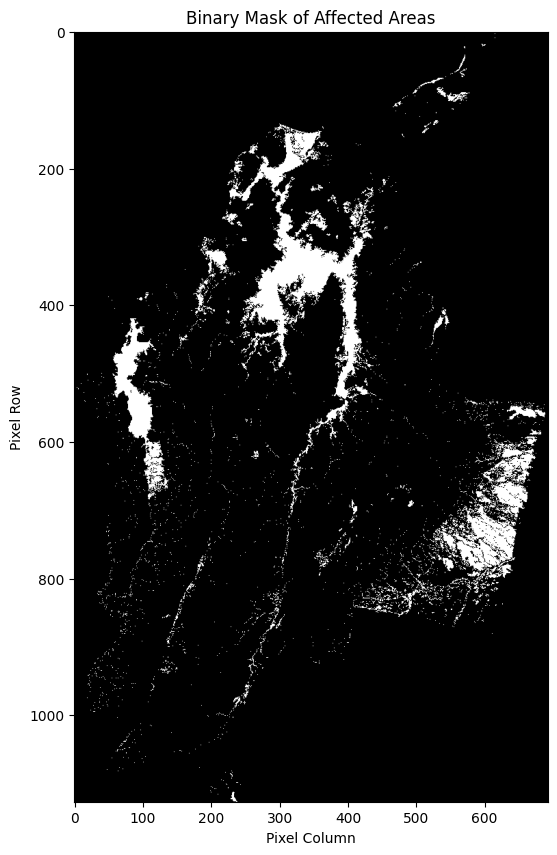

In [ ]:
# Rasterize the geometries to create a binary mask
shapes = [(geom, 1) for geom in gdf_inun11.geometry]

# Create an empty raster
mask = rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype='uint8'
)

# Display the mask (optional, for verification)
plt.figure(figsize=(10, 10))
plt.imshow(mask, cmap='gray')
plt.title('Binary Mask of Affected Areas')
plt.xlabel('Pixel Column')
plt.ylabel('Pixel Row')
plt.show()

## U-net model definition

NOTA: El siguiente modelo no representa el modelo definitivo, es un representación.


**Reasoning**:
Import the necessary modules for defining the U-Net architecture using TensorFlow/Keras.



In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, concatenate, UpSampling2D, Layer
from tensorflow.keras.models import Model
import tensorflow as tf # Import tensorflow as tf

class CropToMatch(Layer):
    def call(self, inputs):
        target_shape, x_to_crop = inputs
        target_h = tf.shape(target_shape)[1]
        target_w = tf.shape(target_shape)[2]
        h_to_crop = tf.shape(x_to_crop)[1]
        w_to_crop = tf.shape(x_to_crop)[2]

        h_diff = h_to_crop - target_h
        w_diff = w_to_crop - target_w

        # Use tf.maximum to handle cases where the tensor to crop is smaller or equal
        cropping_h = tf.maximum(0, h_diff // 2)
        cropping_w = tf.maximum(0, w_diff // 2)

        cropped_x = x_to_crop[:, cropping_h:h_to_crop - h_diff + cropping_h,
                              cropping_w:w_to_crop - w_diff + cropping_w, :]

        return cropped_x

    def compute_output_shape(self, input_shape):
        target_shape, x_to_crop_shape = input_shape
        # The output shape should match the target shape in height and width, and the channels of the tensor to crop
        return (x_to_crop_shape[0], target_shape[1], target_shape[2], x_to_crop_shape[3])


def unet_model(input_size=(1127, 693, 1)):
    inputs = Input(input_size)

    # Encoder
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = Conv2D(256, 3, activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(512, 3, activation='relu', padding='same')(pool3)
    conv4 = Conv2D(512, 3, activation='relu', padding='same')(conv4)
    drop4 = tf.keras.layers.Dropout(0.5)(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(drop4)

    # Bottleneck
    conv5 = Conv2D(1024, 3, activation='relu', padding='same')(pool4)
    conv5 = Conv2D(1024, 3, activation='relu', padding='same')(conv5)
    drop5 = tf.keras.layers.Dropout(0.5)(conv5)

    # Decoder
    up6 = Conv2D(512, 2, activation='relu', padding='same')(UpSampling2D(size=(2, 2))(drop5))
    crop6 = CropToMatch()([drop4, up6])
    merge6 = concatenate([drop4, crop6], axis=3)
    conv6 = Conv2D(512, 3, activation='relu', padding='same')(merge6)
    conv6 = Conv2D(512, 3, activation='relu', padding='same')(conv6)

    up7 = Conv2D(256, 2, activation='relu', padding='same')(UpSampling2D(size=(2, 2))(conv6))
    crop7 = CropToMatch()([conv3, up7])
    merge7 = concatenate([conv3, crop7], axis=3)
    conv7 = Conv2D(256, 3, activation='relu', padding='same')(merge7)
    conv7 = Conv2D(256, 3, activation='relu', padding='same')(conv7)

    up8 = Conv2D(128, 2, activation='relu', padding='same')(UpSampling2D(size=(2, 2))(conv7))
    crop8 = CropToMatch()([conv2, up8])
    merge8 = concatenate([conv2, crop8], axis=3)
    conv8 = Conv2D(128, 3, activation='relu', padding='same')(merge8)
    conv8 = Conv2D(128, 3, activation='relu', padding='same')(conv8)

    up9 = Conv2D(64, 2, activation='relu', padding='same')(UpSampling2D(size=(2, 2))(conv8))
    crop9 = CropToMatch()([conv1, up9])
    merge9 = concatenate([conv1, crop9], axis=3)
    conv9 = Conv2D(64, 3, activation='relu', padding='same')(merge9)
    conv9 = Conv2D(64, 3, activation='relu', padding='same')(conv9)
    conv9 = Conv2D(2, 3, activation='relu', padding='same')(conv9)

    # Output layer
    outputs = Conv2D(1, 1, activation='sigmoid')(conv9)

    model = Model(inputs=inputs, outputs=outputs)

    return model

# Create the model
unet_model = unet_model()

# Display the model summary
unet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1127, 693, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 1127, 693, │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 1127, 693, │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 563, 346,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 563, 346,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 563, 346,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 281, 173,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 281, 173,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 281, 173,  │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 140, 86,   │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 140, 86,   │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 140, 86,   │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 140, 86,   │          0 │ conv2d_7[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 70, 43,    │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 70, 43,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 70, 43,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 70, 43,    │          0 │ conv2d_9[0][0]  

 Total params: 31,031,685 (118.38 MB)

 Trainable params: 31,031,685 (118.38 MB)

 Non-trainable params: 0 (0.00 B)